In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load your dataset
data = pd.read_csv('digital.csv')

print(data.tail(5))

# Replace non-numeric entries with NaN (e.g., 'gg' is not a number)
for column in ['field1', 'field2', 'field3', 'field4', 'field5', 'field6', 'field7', 'field8']:
    data[column] = pd.to_numeric(data[column], errors='coerce')

# Check for NaN values
print(data[['field1', 'field2', 'field3', 'field4', 'field5', 'field6', 'field7', 'field8']].isna().sum())

# You can drop rows with NaN values (or handle them differently if you want)
data_clean = data.dropna(subset=['field1', 'field2', 'field3', 'field4', 'field5', 'field6', 'field7', 'field8'])

# Initialize the scaler
scaler = StandardScaler()

# Scale the input features (fields 1 to 8)
scaled_input = scaler.fit_transform(data_clean[['field1', 'field2', 'field3', 'field4', 'field5', 'field6', 'field7', 'field8']])

# Convert the scaled input back to a DataFrame
scaled_input_df = pd.DataFrame(scaled_input, columns=['field1', 'field2', 'field3', 'field4', 'field5', 'field6', 'field7', 'field8'], index=data_clean.index)

# Concatenate the scaled data with 'created_at' and 'entry_id' (no scaling required for these)
scaled_data = pd.concat([data_clean[['created_at', 'entry_id']], scaled_input_df], axis=1)

# Show the last 5 rows of the scaled data
print(scaled_data.tail(5))


                      created_at  entry_id field1  field2  field3  field4  \
18280  2024-07-24T14:05:52+05:30     20226  24.68   22.59   73.64   45.00   
18281  2024-07-24T14:06:07+05:30     20227  24.84   23.33   74.94   45.24   
18282  2024-07-24T14:06:49+05:30     20228  24.36   21.73   77.89   45.59   
18283  2024-07-24T14:07:08+05:30     20229  24.53   20.98   78.88   45.85   
18284  2024-07-24T14:07:59+05:30     20230  24.65   18.18   82.01   46.69   

       field5  field6  field7  field8  
18280   31.20   69.79   50.86   27.17  
18281   30.70   70.69   50.81   27.18  
18282   31.19   72.80   50.94   27.17  
18283   31.29   73.54   51.10   27.09  
18284   30.89   76.01   51.77   27.26  
field1      1
field2      7
field3      9
field4    116
field5    118
field6    119
field7    136
field8    136
dtype: int64
                      created_at  entry_id    field1    field2    field3  \
18280  2024-07-24T14:05:52+05:30     20226  0.309868  0.139724 -0.242500   
18281  2024-07-24T14

In [6]:
import pandas as pd

# Load your dataset (assuming it's already loaded in 'scaled_data')
# scaled_data = pd.read_csv('digital.csv')  # Uncomment if needed
# scaled_data['created_at'] = pd.to_datetime(scaled_data['created_at'])

# Set the 'created_at' column as the index
scaled_data['created_at'] = pd.to_datetime(scaled_data['created_at'])
scaled_data.set_index('created_at', inplace=True)

# Define the prediction length (in minutes, here 5 minutes)
max_prediction_length = 5

# Last date from the data (assuming the 'created_at' is the datetime column)
last_date = scaled_data.index.max()

# Future date range (next 5 minutes from the last available date)
future_dates = pd.date_range(last_date + pd.Timedelta(minutes=1), periods=max_prediction_length, freq='min')

# Create a DataFrame for the future data (with the same columns)
future_data = pd.DataFrame(index=future_dates, columns=scaled_data.columns).fillna(0)

# Fill the future data with the last available data from the most recent time
for column in future_data.columns:
    future_data[column] = scaled_data[column].iloc[-1]

# Combine historical and future data
scaled_data = pd.concat([scaled_data, future_data])

# Show the last 5 rows of the dataset (including the newly added future data)
print(scaled_data.tail(10))



KeyError: 'created_at'

In [6]:
import pandas as pd
import lightning.pytorch as pl
from pytorch_forecasting import NBeats
from pytorch_forecasting.data import TimeSeriesDataSet, NaNLabelEncoder
import torch
# Assuming 'scaled_data' is already loaded and preprocessed
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
# Check the columns of the scaled_data DataFrame
print(scaled_data.columns)

# If 'created_at' exists in the dataset, proceed with the following steps
if 'created_at' in scaled_data.columns:
    # Convert 'created_at' to datetime and set it as the index for time-based operations
    scaled_data['created_at'] = pd.to_datetime(scaled_data['created_at'])
    scaled_data.set_index('created_at', inplace=True)
else:
    # If no 'created_at' column exists, create a synthetic datetime index (for example)
    print("Column 'created_at' not found. Creating a synthetic datetime index.")
    scaled_data['created_at'] = pd.date_range(start="2024-01-01", periods=len(scaled_data), freq='T')  # 'T' is minute-level frequency
    scaled_data.set_index('created_at', inplace=True)

# Add time_idx (index of the time dimension) and group
scaled_data['group'] = 'dummy_group'  # Assuming a single group (you can change this if needed)
scaled_data['time_idx'] = range(len(scaled_data))

# Reset the index to make 'created_at' a column again
scaled_data.reset_index(inplace=True)

# Define the target column
target_column = 'field1'  # Only predict 'field1'

# Columns for time-varying known and unknown real features
time_varying_known_reals = []  # No known real variables for time-varying features
time_varying_unknown_reals = [target_column]  # Predicting only 'field1'

# Set parameters for N-BEATS
max_encoder_length = 5  # You can adjust this based on your time series
max_prediction_length = 5  # For predicting the next 5 time steps
context_length = max_encoder_length  # Same as encoder length

# Create the TimeSeriesDataSet for 'field1'
training = TimeSeriesDataSet(
    scaled_data,
    time_idx="time_idx",  # Time column
    group_ids=["group"],  # Group column (dummy in this case)
    target=target_column,  # Target column is just 'field1'
    categorical_encoders={"group": NaNLabelEncoder().fit(scaled_data.group)},  # Encoding for categorical variables
    time_varying_known_reals=time_varying_known_reals,  # Known time-varying features (none in this case)
    time_varying_unknown_reals=time_varying_unknown_reals,  # Target 'field1' is the unknown time-varying feature
    max_encoder_length=max_encoder_length,  # Length of the encoder
    max_prediction_length=max_prediction_length,  # Length of the prediction
    allow_missing_timesteps=True,  # Allow missing time steps if necessary
)

# Split the data into training and validation sets
training_cutoff = scaled_data["time_idx"].max() - max_prediction_length  # Use the last part for validation
validation = TimeSeriesDataSet.from_dataset(
    training,
    scaled_data,
    min_prediction_idx=training_cutoff + 1  # Ensuring no data overlap between training and validation
)

# Create dataloaders for training and validation
batch_size = 64  # Set your batch size
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

# Initialize the N-BEATS model for predicting just 'field1'
net = NBeats.from_dataset(
    training,
    learning_rate=0.003,
    log_interval=10,
    log_val_interval=1,
    weight_decay=0.001,
    widths=[64, 1024],  # Layer sizes
    backcast_loss_ratio=0.16,
    num_blocks=[3, 3, 3],  # Number of blocks in each stack
)

# Initialize the Trainer
trainer = pl.Trainer(
    max_epochs=200,
    accelerator="gpu",  # Use GPU
    devices=1,  # Number of GPUs to use (can be adjusted to match the available GPUs)
    enable_model_summary=True,
    gradient_clip_val=0.01,
    limit_train_batches=150,
)

# Fit the model
trainer.fit(
    net,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)



C:\Users\Sai_Kiran\PycharmProjects\Artificial_Intelligence\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
C:\Users\Sai_Kiran\PycharmProjects\Artificial_Intelligence\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
C:\Users\Sai_Kiran\PycharmProjects\Artificial_Intelligence\.venv\Lib\site-packages\pytorch_forecasting\models\nbeats\__init__.py:107: UserWarning: In pytorch-forecasting models, on versions 1.1.X, the default optimizer defaults to 'adam', if pytorch_optimizer is not installed, otherwise it defaults to 'ranger' from pytorch_optimizer. From version 1.2.0, the default optimi

cuda
Index(['created_at', 'entry_id', 'field1', 'field2', 'field3', 'field4',
       'field5', 'field6', 'field7', 'field8', 'group', 'time_idx'],
      dtype='object')



  | Name            | Type       | Params | Mode 
-------------------------------------------------------
0 | loss            | MASE       | 0      | train
1 | logging_metrics | ModuleList | 0      | train
2 | net_blocks      | ModuleList | 6.4 M  | train
-------------------------------------------------------
6.4 M     Trainable params
0         Non-trainable params
6.4 M     Total params
25.432    Total estimated model params size (MB)
86        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\Sai_Kiran\PycharmProjects\Artificial_Intelligence\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
C:\Users\Sai_Kiran\PycharmProjects\Artificial_Intelligence\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


Available columns in scaled_data: Index(['created_at', 'entry_id', 'field1', 'field2', 'field3', 'field4',
       'field5', 'field6', 'field7', 'field8', 'group', 'time_idx'],
      dtype='object')
Shape of predictions: (1, 5)
Predicted values for the next steps:
[0.29682383 0.29574415 0.29449818 0.29246813 0.2896249 ]
MAPE: 3.72%
Accuracy: 96.28%


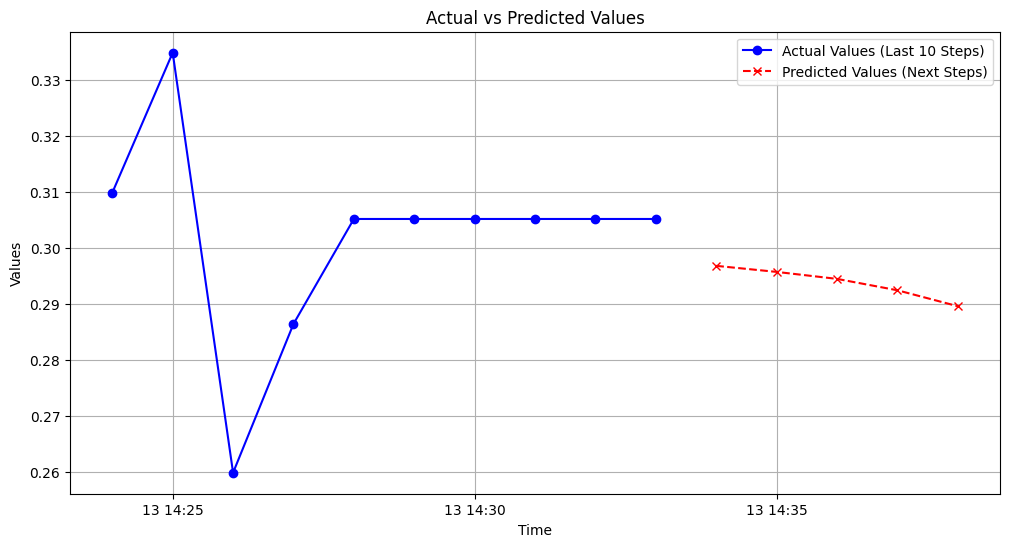

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

# Debugging step: Check the available columns in scaled_data
print("Available columns in scaled_data:", scaled_data.columns)

# Update column name based on your dataset
column_name = 'field1'  # Replace this with the actual column name

# Ensure the index of scaled_data is datetime
if not isinstance(scaled_data.index, pd.DatetimeIndex):
    scaled_data['created_at'] = pd.to_datetime(scaled_data['created_at'])
    scaled_data.set_index('created_at', inplace=True)

# Get the model predictions for the validation dataset
model = net  # This is your trained N-BEATS model

# Use the validation dataloader to predict the next time steps
predictions = []
model.eval()  # Set the model to evaluation mode

with torch.no_grad():  # No need to compute gradients during inference
    for batch in val_dataloader:
        x, y = batch  # x: input features, y: actual target values
        output = model(x)  # Make the prediction
        
        # Extract the predicted values from the output object
        preds = output[0].detach().cpu().numpy()  # Adjusting to access the correct part of the output
        predictions.append(preds)  # Append the predictions

# Concatenate the predictions
predictions = np.concatenate(predictions, axis=0)

# Print the shape of predictions to check its size
print("Shape of predictions:", predictions.shape)

# Get predicted values for the first batch
predicted_values = predictions[0, :]  # First batch (shape: (1, max_prediction_length))

# Print the predicted values
print("Predicted values for the next steps:")
print(predicted_values)

# Get the actual values corresponding to the predicted time range
actual_values = scaled_data[column_name][-len(predicted_values):].values

# Ensure the lengths match
if len(predicted_values) != len(actual_values):
    raise ValueError(f"Length mismatch: predicted_values has {len(predicted_values)} values, but actual_values has {len(actual_values)} values")

# Calculate MAPE
mape = np.mean(np.abs((actual_values - predicted_values) / actual_values)) * 100
accuracy = 100 - mape

# Print MAPE and accuracy score
print(f"MAPE: {mape:.2f}%")
print(f"Accuracy: {accuracy:.2f}%")

# Create a time range for the predicted values
last_time = scaled_data.index[-1]
future_time = pd.date_range(last_time + pd.Timedelta(minutes=1), periods=len(predicted_values), freq='min')

# Create a DataFrame for the predicted values
predicted_df = pd.DataFrame({
    'created_at': future_time,
    'predicted_values': predicted_values
})

# Get the last few actual values for comparison
lookback_steps = 10  # Number of past time steps to show before prediction
past_values = scaled_data[column_name][-lookback_steps:]

# Plot actual past values, actual future values, and predicted future values
plt.figure(figsize=(12, 6))
plt.plot(past_values.index, past_values.values, label='Actual Values (Last 10 Steps)', color='blue', marker='o')
plt.plot(predicted_df['created_at'], predicted_df['predicted_values'], label='Predicted Values (Next Steps)', color='red', linestyle='--', marker='x')
plt.title('Actual vs Predicted Values')
plt.xlabel('Time')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.show()
